<a href="https://colab.research.google.com/github/maheshkumar30/DataScience/blob/main/Covid_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from prophet import Prophet
from prophet.plot import plot_plotly

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("covid_19_clean_complete.csv")

In [3]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16515 entries, 0 to 16514
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  4956 non-null   object 
 1   Country/Region  16515 non-null  object 
 2   Lat             16515 non-null  float64
 3   Long            16515 non-null  float64
 4   Date            16515 non-null  object 
 5   Confirmed       16515 non-null  int64  
 6   Deaths          16515 non-null  int64  
 7   Recovered       16515 non-null  int64  
 8   Active          16515 non-null  int64  
 9   WHO Region      16515 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 1.3+ MB


,0
Province/State,11559
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
df['Active'] = df['Confirmed'] - df['Deaths'] - df['Recovered']

#**Worldwide COVID Trend**
Aggregate worldwide data

In [6]:
world = df.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

#**Interactive Visualization using Plotly**
Confirmed Cases Trend

In [7]:
fig = px.line(world,
              x='Date',
              y='Confirmed',
              title='Worldwide Confirmed COVID-19 Cases')

fig.show()

In [8]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=world['Date'],
                         y=world['Active'],
                         mode='lines',
                         name='Active'))

fig.add_trace(go.Scatter(x=world['Date'],
                         y=world['Recovered'],
                         mode='lines',
                         name='Recovered'))

fig.add_trace(go.Scatter(x=world['Date'],
                         y=world['Deaths'],
                         mode='lines',
                         name='Deaths'))

fig.update_layout(title='COVID-19 Trend Analysis')

fig.show()

#**India COVID Analysis**
Filter India data

In [9]:
india = df[df['Country/Region'] == 'India']

india = india.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

**India Confirmed Cases**

In [10]:
fig = px.line(india,
              x='Date',
              y='Confirmed',
              title='India COVID-19 Confirmed Cases')

fig.show()

#**Recovery Rate & Death Rate**
Recovery Rate

In [11]:
world['Recovery Rate'] = (world['Recovered'] / world['Confirmed']) * 100

**Death Rate**

In [12]:
world['Death Rate'] = (world['Deaths'] / world['Confirmed']) * 100

**Visualize Rates**

In [13]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=world['Date'],
                         y=world['Recovery Rate'],
                         name='Recovery Rate'))

fig.add_trace(go.Scatter(x=world['Date'],
                         y=world['Death Rate'],
                         name='Death Rate'))

fig.update_layout(title='Recovery vs Death Rate')

fig.show()

#**Forecasting using Prophet**

We forecast confirmed cases for the next 7 days.

Prepare data for Prophet

In [14]:
prophet_df = world[['Date','Confirmed']]

prophet_df.columns = ['ds','y']

**Create Model**

In [15]:
model = Prophet()

model.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


**Future Prediction (7 days)**

In [16]:
future = model.make_future_dataframe(periods=7)

forecast = model.predict(future)

#**Visualize Forecast**
Interactive Forecast

In [17]:
fig = plot_plotly(model, forecast)

fig.show()

#**Forecast Components**

1. Shows:

    * Trend
    * Weekly patterns
    * Seasonality

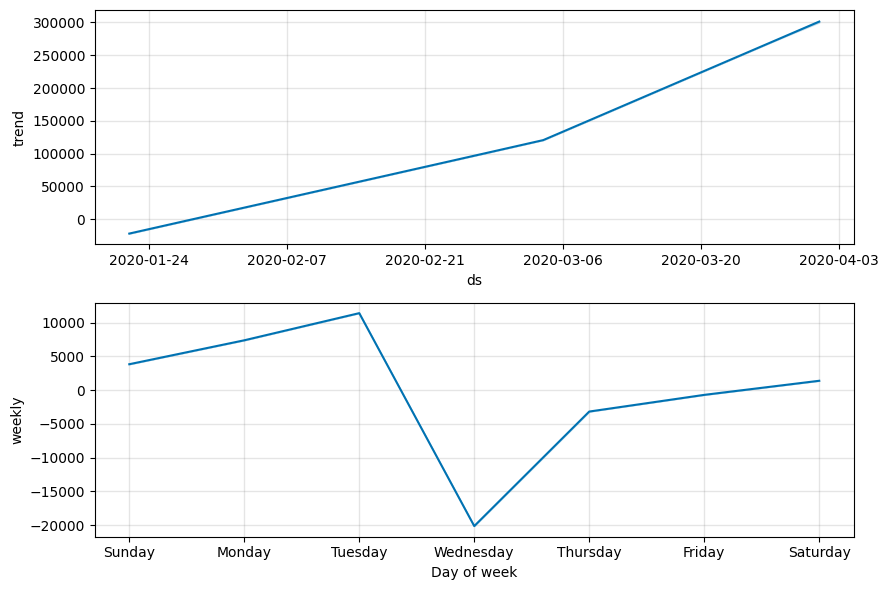

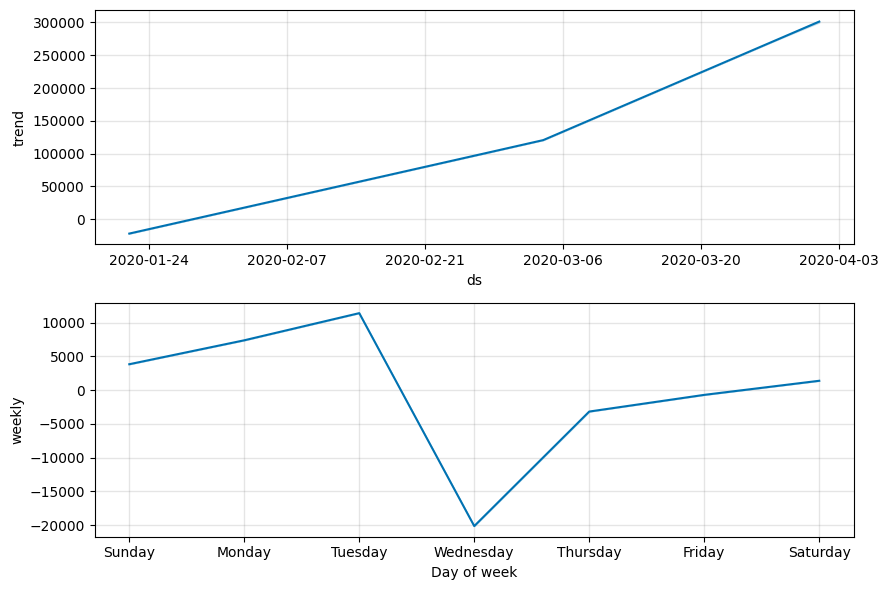

In [18]:
model.plot_components(forecast)

#**Top Countries by Confirmed Cases**

In [19]:
latest = df[df['Date'] == df['Date'].max()]

top = latest.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)

top = top.reset_index()

**Visualization**

In [20]:
fig = px.bar(top,
             x='Country/Region',
             y='Confirmed',
             title='Top 10 Countries by Confirmed Cases')

fig.show()